## TASK 1


In [33]:
from datasets import load_dataset

dataset = load_dataset("roneneldan/TinyStories")
dataset

for i in range(3):
    print(f"Story {i+1}\n")
    print(dataset["train"][i]["text"][:700])
    print("\n" + "="*80)

Story 1

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together

Story 2

Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves th

A language model takes a sequence of tokens as input and predicts the next token that should follow. In the TinyStories dataset, the model is trained on short story text, so it learns vocabulary, grammar, sentence structure, and how simple stories are written. The output at each step is the model’s prediction for the next token, and by making many such predictions it can generate complete text.


--------------------------

## TASK 2

In [34]:
import os
import numpy as np
import tiktoken
from datasets import load_dataset

dataset = load_dataset("roneneldan/TinyStories")

# Encode one sentence and decode it back

enc = tiktoken.get_encoding("gpt2")

sample_text = "Once upon a time, there was a tiny dragon."
token_ids = enc.encode(sample_text)

print("Original Text: ")
print(sample_text)

print("\nToken IDs: ")
print(token_ids)

print("\nDecoded back: ")
print(enc.decode(token_ids))
print("\n")

enc.eot_token

def tokenize_example(example):
    ids = enc.encode(example["text"])
    ids.append(enc.eot_token)
    return {
        "ids" : ids,
        "len" : len(ids)
    }

tokenized = dataset.map(
    tokenize_example,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing dataset"
)

print(tokenized)
print("\nSample tokenized example: ")
print(tokenized["train"][0])

# Save tokenized train/val splits to .bin using numpy.memmap
train_token_count = np.sum(tokenized["train"]["len"], dtype=np.int64)
val_token_count = np.sum(tokenized["validation"]["len"], dtype=np.int64)

print("\nTrain token count:", train_token_count)
print("Validation token count:", val_token_count)

def write_split_to_bin(split_dataset, filename):
    arr_len = np.sum(split_dataset["len"], dtype=np.int64)
    arr = np.memmap(filename, dtype=np.uint16, mode="w+", shape=(arr_len,))

    idx = 0
    for example in split_dataset:
        ids = np.array(example["ids"], dtype=np.uint16)
        arr[idx: idx + len(ids)] = ids
        idx += len(ids)

    arr.flush()
    print(f"Saved {filename} with {arr_len} tokens")

write_split_to_bin(tokenized["train"], "train.bin")
write_split_to_bin(tokenized["validation"], "val.bin")

#Verify files exist
print("\ntrain.bin exists:", os.path.exists("train.bin"))
print("val.bin exists:", os.path.exists("val.bin"))

#Load train.bin back with numpy.memmap
train_ids = np.memmap("train.bin", dtype=np.uint16, mode="r")
val_ids = np.memmap("val.bin", dtype=np.uint16, mode="r")

print("\nLoaded back from disk:")
print("Train tokens:", len(train_ids))
print("Validation tokens:", len(val_ids))

#Decode first fifty tokens
first_50_ids = train_ids[:50].tolist()

print("\nFirst 50 token IDs:")
print(first_50_ids)

decoded_text = enc.decode(first_50_ids)
print("\nDecoded text from first 50 token IDs:")
print(decoded_text)

Original Text: 
Once upon a time, there was a tiny dragon.

Token IDs: 
[7454, 2402, 257, 640, 11, 612, 373, 257, 7009, 10441, 13]

Decoded back: 
Once upon a time, there was a tiny dragon.


DatasetDict({
    train: Dataset({
        features: ['ids', 'len'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['ids', 'len'],
        num_rows: 21990
    })
})

Sample tokenized example: 
{'ids': [3198, 1110, 11, 257, 1310, 2576, 3706, 20037, 1043, 257, 17598, 287, 607, 2119, 13, 1375, 2993, 340, 373, 2408, 284, 711, 351, 340, 780, 340, 373, 7786, 13, 20037, 2227, 284, 2648, 262, 17598, 351, 607, 1995, 11, 523, 673, 714, 34249, 257, 4936, 319, 607, 10147, 13, 198, 198, 43, 813, 1816, 284, 607, 1995, 290, 531, 11, 366, 29252, 11, 314, 1043, 428, 17598, 13, 1680, 345, 2648, 340, 351, 502, 290, 34249, 616, 10147, 1701, 2332, 1995, 13541, 290, 531, 11, 366, 5297, 11, 20037, 11, 356, 460, 2648, 262, 17598, 290, 4259, 534, 10147, 526, 198, 198, 41631, 11, 484, 4888, 2

-----------------

## TASK 3

In [35]:
import numpy as np
import torch

train_data = np.memmap("train.bin",dtype=np.uint16,mode="r")
val_data = np.memmap("val.bin",dtype=np.uint16,mode="r")

print("Train tokens:", len(train_data))
print("Validation tokens: ",len(val_data))

batch_size=8
block_size=32

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device: ",device)

def get_batch(split):
    data=train_data if split=="train" else val_data

    ix = torch.randint(len(data)-block_size-1, (batch_size,))

    x = torch.stack([
        torch.tensor(data[i:i+block_size].astype(np.int64))
        for i in ix
    ])

    y = torch.stack([
        torch.tensor(data[i+1:i+block_size+1].astype(np.int64))
        for i in ix
    ])

    x = x.to(device)
    y = y.to(device)

    return x,y


x, y = get_batch("train")

print("\nTrain batch:")
print("x shape:", x.shape)
print("y shape:", y.shape)

print("\nFirst sample x:")
print(x[0])

print("\nFirst sample y:")
print(y[0])

print("\nCheck shift:")
print("x[0][1:11] =", x[0][1:11].tolist())
print("y[0][0:10] =", y[0][0:10].tolist())


x_val, y_val = get_batch("val")
print("\nValidation batch:")
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

Train tokens: 473992236
Validation tokens:  4765918
Using device:  cuda

Train batch:
x shape: torch.Size([8, 32])
y shape: torch.Size([8, 32])

First sample x:
tensor([ 1755,   673,  3521,   470,  4043,   284,  1234,   606,   319,   290,
          905,   606,   572,     0,   198,   198,  2953,   262,   886,   286,
         1123,  1110,    11,   262,   649, 38619,   373, 19064,   475,   523,
         3772,    13], device='cuda:0')

First sample y:
tensor([  673,  3521,   470,  4043,   284,  1234,   606,   319,   290,   905,
          606,   572,     0,   198,   198,  2953,   262,   886,   286,  1123,
         1110,    11,   262,   649, 38619,   373, 19064,   475,   523,  3772,
           13,  2332], device='cuda:0')

Check shift:
x[0][1:11] = [673, 3521, 470, 4043, 284, 1234, 606, 319, 290, 905]
y[0][0:10] = [673, 3521, 470, 4043, 284, 1234, 606, 319, 290, 905]

Validation batch:
x_val shape: torch.Size([8, 32])
y_val shape: torch.Size([8, 32])


-----------------------------

## TASK 4

In [48]:
import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class GPTConfig: #Stores the model hyperparameters
    vocab_size: int
    block_size: int #Maximum squeeze length
    n_layer: int #Number of transformer blocks stacked together
    n_head: int #Contains multiple attention heads
    n_embd: int #Every token becomes a vector length of n
    dropout: float

class Head(nn.Module): #This is one attention head
    def __init__(self, head_size, config):
        super().__init__()
        self.key = nn.Linear(config.n_embd, head_size, bias=False)
        self.query = nn.Linear(config.n_embd, head_size, bias=False)
        self.value = nn.Linear(config.n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(config.block_size, config.block_size))
        )

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        B, T, C = x.shape

        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)

        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))

        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v

        return out


class MultiHeadAttention(nn.Module): #GPT uses multiple attention heads in parallel
    def __init__(self, num_heads, head_size, config):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, config) for _ in range(num_heads)])
        self.proj = nn.Linear(num_heads * head_size, config.n_embd)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        out = self.dropout(out)
        return out


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        head_size = config.n_embd // config.n_head
        self.sa = MultiHeadAttention(config.n_head, head_size, config)
        self.ffwd = FeedForward(config)
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x



class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.token_embedding_table = nn.Embedding(config.vocab_size, config.n_embd)
        self.position_embedding_table = nn.Embedding(config.block_size, config.n_embd)

        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size)

    def forward(self, idx):
        B, T = idx.shape

        if T > self.config.block_size:
            raise ValueError(
                f"Sequence length {T} exceeds block size {self.config.block_size}"
            )

        tok_emb = self.token_embedding_table(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding_table(pos)

        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        return logits

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]
            logits = self(idx_cond)
            logits = logits[:, -1, :]           # (B, vocab_size)
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_token), dim=1)
        return idx

config = GPTConfig(
    vocab_size=50257,
    block_size=128,
    n_layer=6,
    n_head=6,
    n_embd=256,
    dropout=0.1
)

model = GPT(config)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

batch_size = 4
dummy_input = torch.randint(0, config.vocab_size, (batch_size, config.block_size))
logits = model(dummy_input)

print("Dummy input shape:", dummy_input.shape)
print("Output logits shape:", logits.shape)

Total parameters: 30,524,497
Dummy input shape: torch.Size([4, 128])
Output logits shape: torch.Size([4, 128, 50257])


----------------------------

## TASK 5

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
model=model.to(device)
print("Using device: ",device)

learning_rate=3e-4
weight_decay=0.01

optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

schedular = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100) #T_max is the number of schedular steps over which the LR decays

print("Initial learning rate: ",optimizer.param_groups[0]["lr"])

batch_size = 4
block_size = config.block_size

x_dummy = torch.randint(0, config.vocab_size, (batch_size, block_size), device=device)
y_dummy = torch.randint(0, config.vocab_size, (batch_size, block_size), device=device)

model.train()
optimizer.zero_grad()

logits = model(x_dummy)

B,T,C=logits.shape
loss=nn.functional.cross_entropy(
    logits.view(B*T,C),
    y_dummy.view(B*T)
)

print(f"Dummy Loss: {loss.item():.4f}")

loss.backward()
optimizer.step()
schedular.step()

print(f"Learning rate after one scheduler step: {optimizer.param_groups[0]['lr']:.6f}")

Using device:  cuda
Initial learning rate:  0.0003
Dummy Loss: 10.9931
Learning rate after one scheduler step: 0.000300


-----------------------

## TASK 6

step    0 | train loss 4.5496 | val loss 4.4754
step  500 | train loss 4.0715 | val loss 4.0777
step 1000 | train loss 3.8436 | val loss 3.8196
step 1500 | train loss 3.7314 | val loss 3.5873
step 2000 | train loss 3.5418 | val loss 3.5079
step 2500 | train loss 3.4775 | val loss 3.5602
step 3000 | train loss 3.2785 | val loss 3.2872
step 3500 | train loss 3.2491 | val loss 3.3787
step 4000 | train loss 3.2122 | val loss 3.3046
step 4500 | train loss 3.0975 | val loss 3.2303
step 5000 | train loss 3.1379 | val loss 3.2548
step 5500 | train loss 3.0248 | val loss 2.9909
step 6000 | train loss 3.0393 | val loss 3.1367
step 6500 | train loss 3.0627 | val loss 3.1348
step 7000 | train loss 3.1394 | val loss 2.9288
step 7500 | train loss 2.9632 | val loss 2.9742
step 8000 | train loss 2.9480 | val loss 2.8846
step 8500 | train loss 2.8857 | val loss 2.9762
step 9000 | train loss 2.9875 | val loss 2.9353
step 9500 | train loss 2.9691 | val loss 2.9417
step 9999 | train loss 2.9910 | val loss

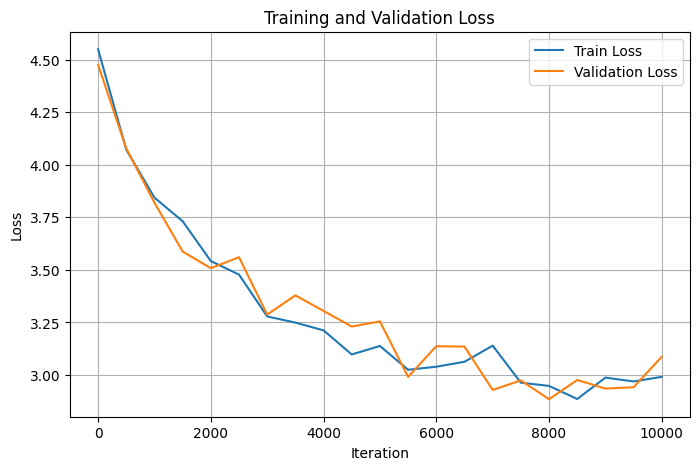

In [43]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

max_iters = 10000
eval_interval = 500
eval_iters = 20

learning_rate = 3e-4
weight_decay = 0.01

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max_iters
)

best_val_loss = float("inf")
best_checkpoint_path = "best_gpt_checkpoint.pt"

train_loss_history = []
val_loss_history = []
eval_steps = []

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            logits = model(x)

            B, T, C = logits.shape
            loss = F.cross_entropy(
                logits.view(B * T, C),
                y.view(B * T)
            )
            losses[k] = loss.item()

        out[split] = losses.mean().item()

    model.train()
    return out


for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_loss = losses["train"]
        val_loss = losses["val"]

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        eval_steps.append(iter)

        print(f"step {iter:4d} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_checkpoint_path)

    x, y = get_batch("train")

    logits = model(x)

    B, T, C = logits.shape
    loss = F.cross_entropy(
        logits.view(B * T, C),
        y.view(B * T)
    )

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    scheduler.step()

print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Best checkpoint saved at: {best_checkpoint_path}")
print("Checkpoint exists:", os.path.exists(best_checkpoint_path))

plt.figure(figsize=(8, 5))
plt.plot(eval_steps, train_loss_history, label="Train Loss")
plt.plot(eval_steps, val_loss_history, label="Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

---------------------

## TASK 7

Loaded checkpoint from: best_gpt_checkpoint.pt
Validation loss: 3.0264
Validation perplexity: 20.6225


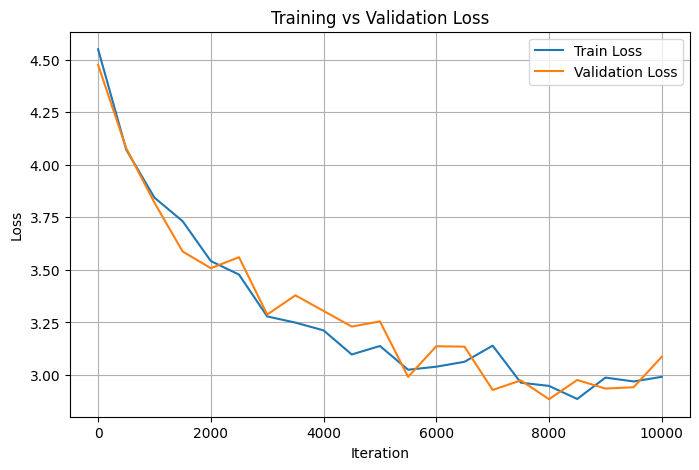

SAMPLE 1

PROMPT: Once upon a time

Once upon a time, there was a little girl named Lily. She loved Today, but first she wanted to go to the kitchen. One day, she saw a boy named Timmy teasing her sad thing on the wall. Timmy saw that Lily was sad, but he also wanted to eat his toy.

"No, can," Timmy said. "Don't worry, and I know that instead. You can help we candy here?"

Timmy was scared at Tom, feeling bad. He wanted to help. But no longer noise. He tried to grab his balance to landed in the garden



SAMPLE 2

PROMPT: The little girl walked into the forest

The little girl walked into the forest with her friends who lived in a little girl who got even healthy and he saw lots of clothes. It was his little girl's surprise and the princess started to mix over an original King.

The little girl grabbed someubby sang up feeling forever. The girl only three year oldly, but she one grill was so wide that she screamed no fruit. Her friend was safe, and apolog smiled and told for help. Dai

In [47]:
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import tiktoken

enc = tiktoken.get_encoding("gpt2")

model = GPT(config).to(device)
checkpoint_path = "best_gpt_checkpoint.pt"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Loaded checkpoint from: {checkpoint_path}")

@torch.no_grad()
def compute_val_loss(eval_iters=50):
    model.eval()
    losses = torch.zeros(eval_iters)

    for k in range(eval_iters):
        x, y = get_batch("val")
        logits = model(x)

        B, T, C = logits.shape
        loss = F.cross_entropy(
            logits.view(B * T, C),
            y.view(B * T)
        )
        losses[k] = loss.item()

    avg_val_loss = losses.mean().item()
    model.train()
    return avg_val_loss

val_loss = compute_val_loss(eval_iters=50)
perplexity = math.exp(val_loss)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation perplexity: {perplexity:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(eval_steps, train_loss_history, label="Train Loss")
plt.plot(eval_steps, val_loss_history, label="Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

@torch.no_grad()
def generate_from_prompt(prompt, max_new_tokens=100):
    model.eval()

    input_ids = enc.encode(prompt)
    x = torch.tensor([input_ids], dtype=torch.long, device=device)

    output_ids = model.generate(x, max_new_tokens=max_new_tokens)[0].tolist()
    generated_text = enc.decode(output_ids)
    return generated_text

prompts = [
    "Once upon a time",
    "The little girl walked into the forest",
    "There was a king who",
    "At midnight, the door slowly opened and"
]

for i, prompt in enumerate(prompts, 1):
    print(f"SAMPLE {i}\n")
    print(f"PROMPT: {prompt}\n")
    generated = generate_from_prompt(prompt, max_new_tokens=120)
    print(generated)
    print()
    print("=" * 80)
    print("\n")


-------------

## TASK 8

In [49]:
import torch
import tiktoken

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

model.load_state_dict(torch.load("best_gpt_checkpoint.pt", map_location=device))
model.eval()

print("Best checkpoint loaded successfully!\n")

enc = tiktoken.get_encoding("gpt2")

prompt = "Once upon a time"

input_ids = enc.encode(prompt)

x = torch.tensor([input_ids], dtype=torch.long, device=device)

print("=" * 80)
print("TEMPERATURE = 0.7\n")

output = model.generate(
    x.clone(),
    max_new_tokens=100,
    temperature=0.7
)

generated_text = enc.decode(output[0].tolist())
print(generated_text)

print("\n" + "=" * 80)
print("TEMPERATURE = 1.2\n")

output = model.generate(
    x.clone(),
    max_new_tokens=100,
    temperature=1.2
)

generated_text = enc.decode(output[0].tolist())
print(generated_text)


Best checkpoint loaded successfully!

TEMPERATURE = 0.7

Once upon a time there was a kind girl named Lily. She loved to paint together with her family. One day, they saw something naughty in the forest. They had a hot spot in the sea. They wanted to play tag and find their treasure. So, they went to find a beautiful park. Lily took a kiss and tucked the bird flew over the cave. 

"Who cannot what's wrong," said her. But that Lily didn't know how to crawl. So, they decided to say goodbye

TEMPERATURE = 1.2

Once upon a time, there was a big rabbits that sand. It was very happy again. It was its friends ever to take care of the problem and the blowing. 

After all the mud, they got into the grass. The same pole helped its landscape and got to make it take them bigger and laughing. The tree bit it bigger from extra time it, still making lots of voices brilliantly that it was. 

They ate, stories laughed and agreed reminded them all the new place. Whenever they


### Temperature = 0.7

I feel the generated text is more coherent and grammatically correct.

----------------------------

### Temperature = 1.2
The generated text is diverse and there contains grammatical errors and topic drift.